# Temas Tratados en el Trabajo Práctico 8

* Aprendizaje estadístico.

* Evolución de la verosimilitud de una hipótesis en función de observaciones.

* Aprendizaje no supervisado. Algoritmo K-means.

* Aprendizaje supervisado. Algoritmo Knn.

* Aprendizaje por refuerzo. Algoritmo Q-Learning.

## Ejercicios Teóricos

1. Un fabricante de tornillos vende cajas que contienen 1000 tornillos de cabeza redonda con tres tipos de recubrimiento electrolítico (cincado, cobre y níquel). Cada caja se rellena
con diferentes proporciones que pueden variar de la siguiente manera:

&emsp;&emsp;a: Todos los tornillos están recubiertos de níquel. 15 de cada 100 cajas se llenan de esta manera.

&emsp;&emsp;b: El 70% de los tornillos están recubiertos de níquel, el 20% de cobre, el resto está cincado. 15 de cada 100 cajas se llenan de esta manera.

&emsp;&emsp;c: El 50% de los tornillos están recubiertos de níquel, el 25% de cobre y el resto está cincado. 50 de cada 100 cajas se llenan de esta manera.

&emsp;&emsp;d: El 20 % de los tornillos están recubiertos de níquel, el 50% de cobre y el resto está cincado. 10 de cada 100 cajas se llenan de esta manera.

&emsp;&emsp;e: Todos los tornillos están recubiertos de cobre. 10 de cada 100 cajas se llenan de esta manera.

&emsp;&emsp;1.1 ¿Cuál es la distribución a priori sobre las hipótesis?

&emsp;Considerando que los 10 primeros tornillos que se extraen de una caja de muestra son de cobre:

&emsp;&emsp;1.2 Calcule la probabilidad de cada hipótesis dado que los 10 primeros tornillos fueron de cobre.


&emsp;&emsp;1.3 Grafique la evolución de la verosimilitud de cada hipótesis en función del número de tornillos extraídos de la caja.

&emsp;&emsp;1.4 Para cada hipótesis, ¿cuál es la probabilidad de que el cuarto tornillo extraído sea de cobre?

2. ¿Qué diferencia principal existe entre un algoritmo supervisado y un algoritmo no supervisado?

En un algoritmo supervisado, el algoritmo aprende a partir de un conjunto de datos de entrenamiento que ha sido previamente etiquetado, el objetivo de este es aprender una funcion o "mapeo" que pueda predecir la salida correcta para nuevos datos de entrada que no ha visto antes. En cambio un algoritmo no supervisado, el algoritmo trabaja con datos que no estan etiquetados, el principal objetivo es explorar los datos y encontrar patrones, estructuras o agrupaciones inherentes

## Ejercicios de implementación

3. Genere un conjunto de 23 puntos que contengan coordenadas *xy* aleatorias con valores contenidos en el intervalo [0, 5] y grafique los puntos obtenidos en un gráfico.

&emsp;&emsp;3.1 Implemente un algoritmo K-means que clasifique 20 de los puntos en 2 grupos y grafique el resultado asignando un color a cada uno.

--- Inicialización ---
Centroides iniciales aleatorios:
[[3.48714959 4.65051402]
 [4.40836374 0.47485992]]

Algoritmo convergido en la iteración 2 por estabilidad de centroides.

--- Resultados Finales ---
Centroides finales:
[[2.34070608 3.83963062]
 [3.15164848 1.10240252]]


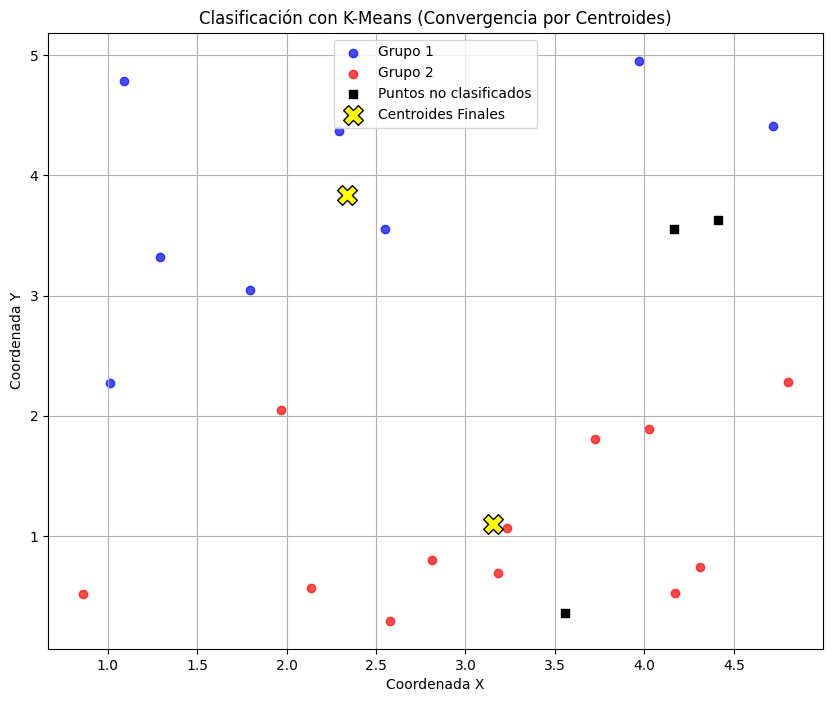

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def ejecutar_kmeans():

    np.random.seed(44)
    datos = np.random.rand(23, 2) * 5
    puntos_a_clasificar = datos[:20]
    puntos_restantes = datos[20:]

    k = 2
    max_iter = 30

    centroides = np.random.rand(k, 2) * 5
    print("--- Inicialización ---")
    print(f"Centroides iniciales aleatorios:\n{centroides}\n")

    for i in range(max_iter):
        # Se guarda una copia de los centroides antes de la actualización.
        centroides_anteriores = centroides.copy()

        #Asignamos
        asignaciones = np.zeros(puntos_a_clasificar.shape[0], dtype=int)
        for j, punto in enumerate(puntos_a_clasificar):
            distancias = [np.linalg.norm(punto - centroide) for centroide in centroides]
            asignaciones[j] = np.argmin(distancias)

        #Actualizamos
        for cluster_idx in range(k):
            puntos_en_cluster = puntos_a_clasificar[asignaciones == cluster_idx]
            if len(puntos_en_cluster) > 0:
                centroides[cluster_idx] = puntos_en_cluster.mean(axis=0)

        #Comprobamos
        if np.array_equal(centroides, centroides_anteriores):
            print(f"Algoritmo convergido en la iteración {i+1} por estabilidad de centroides.")
            break
        
        if i == max_iter - 1:
            print(f"Algoritmo alcanzó el máximo de {max_iter} iteraciones sin converger.")

    print("\n--- Resultados Finales ---")
    print(f"Centroides finales:\n{centroides}")

    #Graficamos
    plt.figure(figsize=(10, 8))
    colores = ['blue', 'red']
    
    for cluster_idx in range(k):
        puntos_del_cluster = puntos_a_clasificar[asignaciones == cluster_idx]
        plt.scatter(puntos_del_cluster[:, 0], puntos_del_cluster[:, 1], 
                    c=colores[cluster_idx], label=f'Grupo {cluster_idx + 1}', alpha=0.7)

    plt.scatter(puntos_restantes[:, 0], puntos_restantes[:, 1], 
                c='black', marker='s', label='Puntos no clasificados')

    plt.scatter(centroides[:, 0], centroides[:, 1], c='yellow', marker='X', s=200, 
                edgecolors='black', label='Centroides Finales')

    plt.title('Clasificación con K-Means (Convergencia por Centroides)')
    plt.xlabel('Coordenada X')
    plt.ylabel('Coordenada Y')
    plt.legend()
    plt.grid(True)
    plt.show()

# Ejecutar la función
ejecutar_kmeans()


&emsp;&emsp;3.2 Tome los tres puntos restantes y clasifíquelos en los grupos obtenidos anteriormente usando el algoritmo Knn. Utilice distintos valores de K y anote lo que observa con esta elección.

Algoritmo K-Means convergido en la iteración 2.

--- Clasificando 3 puntos restantes con k-NN (k=3) ---
Punto [3.56 0.36] asignado al Grupo 2
Punto [4.41 3.63] asignado al Grupo 1
Punto [4.17 3.55] asignado al Grupo 1


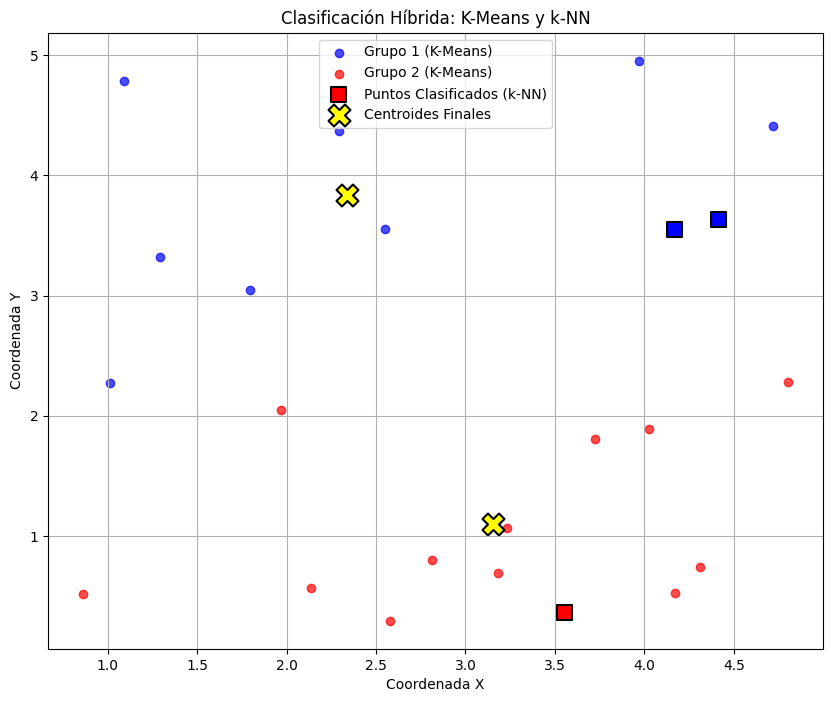

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def ejecutar_kmeans_y_knn():

    np.random.seed(44)
    datos = np.random.rand(23, 2) * 5
    puntos_a_clasificar = datos[:20]
    puntos_restantes = datos[20:]

    k = 2
    max_iter = 30

    centroides = np.random.rand(k, 2) * 5
    
    for i in range(max_iter):
        centroides_anteriores = centroides.copy()
        
        # Asignación
        asignaciones = np.zeros(puntos_a_clasificar.shape[0], dtype=int)
        for j, punto in enumerate(puntos_a_clasificar):
            distancias = [np.linalg.norm(punto - centroide) for centroide in centroides]
            asignaciones[j] = np.argmin(distancias)

        # Actualización
        for cluster_idx in range(k):
            puntos_en_cluster = puntos_a_clasificar[asignaciones == cluster_idx]
            if len(puntos_en_cluster) > 0:
                centroides[cluster_idx] = puntos_en_cluster.mean(axis=0)

        # Verificación de Convergencia
        if np.array_equal(centroides, centroides_anteriores):
            print(f"Algoritmo K-Means convergido en la iteración {i+1}.")
            break
        if i == max_iter - 1:
            print(f"K-Means alcanzó el máximo de {max_iter} iteraciones.")

    k_vecinos = 3 #Numero de vecinos
    predicciones_knn = []
    
    print(f"\n--- Clasificando {len(puntos_restantes)} puntos restantes con k-NN (k={k_vecinos}) ---")

    for punto_nuevo in puntos_restantes:
        #Calculamos distancias
        distancias = [np.linalg.norm(punto_nuevo - p) for p in puntos_a_clasificar]
        
        indices_vecinos = np.argsort(distancias)[:k_vecinos]
        
        etiquetas_vecinos = asignaciones[indices_vecinos]
        
        #Nos fijamos que grupo es mas comun en los vecinos
        prediccion = np.bincount(etiquetas_vecinos).argmax()
        predicciones_knn.append(prediccion)
        print(f"Punto {np.round(punto_nuevo, 2)} asignado al Grupo {prediccion + 1}")

    #Grafico
    plt.figure(figsize=(10, 8))
    colores = ['blue', 'red']
    
    for cluster_idx in range(k):
        puntos_del_cluster = puntos_a_clasificar[asignaciones == cluster_idx]
        plt.scatter(puntos_del_cluster[:, 0], puntos_del_cluster[:, 1], 
                    c=colores[cluster_idx], label=f'Grupo {cluster_idx + 1} (K-Means)', alpha=0.7)

    #Los nuevos 3 puntos
    colores_nuevos = [colores[p] for p in predicciones_knn]
    plt.scatter(puntos_restantes[:, 0], puntos_restantes[:, 1], 
                c=colores_nuevos, marker='s', s=120, 
                edgecolors='black', linewidth=1.5, label='Puntos Clasificados (k-NN)')

    #Centroides finales
    plt.scatter(centroides[:, 0], centroides[:, 1], c='yellow', marker='X', s=250, 
                edgecolors='black', linewidth=1.5, label='Centroides Finales')

    plt.title('Clasificación Híbrida: K-Means y k-NN')
    plt.xlabel('Coordenada X')
    plt.ylabel('Coordenada Y')
    plt.legend()
    plt.grid(True)
    plt.show()

ejecutar_kmeans_y_knn()

4. La imagen mostrada abajo muestra una red de salas y cómo se comunican entre ellas. Implemente un algoritmo Q-Learning con un factor despreciativo $γ = 0.9$. La matriz de recompensas debe asignar un valor de 0 a cada camino accesible y un valor de 100 a caminos que lleven a la sala del tesoro.

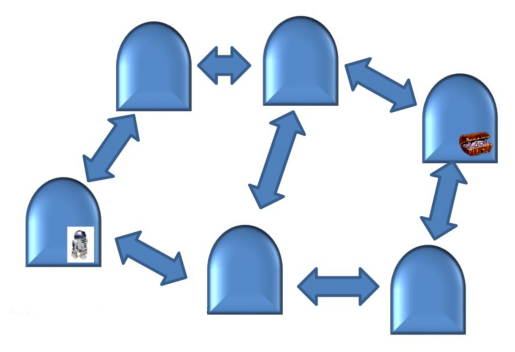

In [1]:
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt

# URL directa de Google Drive
url = "https://drive.google.com/uc?export=view&id=1dkDruEIPa7f-BAmjI47TZl3bxaqYf6a9"

# Descargar la imagen
response = requests.get(url)
img = Image.open(BytesIO(response.content))

# Mostrar la imagen
plt.imshow(img)
plt.axis('off')  # Ocultar ejes
plt.show()

&emsp;&emsp;4.1 Dibuje un diagrama con la asignación de recompensas correspondiente a cada estado.

&emsp;&emsp;4.2 Diseñe y muestre la matriz de recompensas.

&emsp;&emsp;4.3 Obtenga la matriz Q óptima, normalícela respecto al valor máximo encontrado y grafique la política obtenida en el diagrama mostrado inicialmente.

# Bibliografía

[Russell, S. & Norvig, P. (2004) _Inteligencia Artificial: Un Enfoque Moderno_. Pearson Educación S.A. (2a Ed.) Madrid, España](https://www.academia.edu/8241613/Inteligencia_Aritificial_Un_Enfoque_Moderno_2da_Edici%C3%B3n_Stuart_J_Russell_y_Peter_Norvig)

[Poole, D. & Mackworth, A. (2017) _Artificial Intelligence: Foundations of Computational Agents_. Cambridge University Press (3a Ed.) Vancouver, Canada](https://artint.info/3e/html/ArtInt3e.html)